# Plant Disease Classification - PlantVillage Dataset
This project aims to classify **38 different classes** of plant diseases using Transfer Learning.
In this notebook, we utilize the **MobileNetV2** architecture for its efficiency and accuracy in image classification tasks.

In [ ]:
# ---------------------------------------------------------
# Step 1: Import Libraries and Load Dataset
# ---------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, Rescaling, GlobalAveragePooling2D
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json

# Define the path to the dataset directory
data_dir = '/content/data'

# Load the dataset from the directory
# We resize images to 224x224 as required by MobileNetV2
# Using a batch size of 16 to manage memory consumption
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=16,
    label_mode='int',  # Labels are returned as integers for sparse_categorical_crossentropy
    shuffle=True,      # Shuffle data to ensure the model doesn't learn the order
    seed=123           # Seed for reproducibility
)

# Extract and print the class names found in the dataset
class_names = data.class_names
print(f"Total classes found: {len(class_names)}")
print(f"Class names: {class_names}")

# ---------------------------------------------------------
# Note: Ensure the 'data' directory contains 38 subfolders,
# each representing a specific plant disease class.
# ---------------------------------------------------------

### Dataset Splitting and Performance Optimization
In this section, we divide the dataset into three subsets:
1. **Training Set (70%)**: Used to train the model.
2. **Validation Set (20%)**: Used to tune hyperparameters and monitor overfitting.
3. **Test Set (10%)**: Used for final evaluation of the model's performance.

We also use **tf.data.AUTOTUNE** and **prefetching** to optimize the data pipeline, ensuring that the GPU doesn't have to wait for the CPU to load images.

In [2]:
# ---------------------------------------------------------
# Step 2: Split Dataset and Optimize Performance
# ---------------------------------------------------------

# Configure AUTOTUNE to dynamically adjust the number of parallel calls
AUTOTUNE = tf.data.AUTOTUNE

# Apply prefetching to the entire dataset to improve initial loading speed
data = data.prefetch(buffer_size=AUTOTUNE)

# Calculate the number of batches for each split
total_batches = len(data)
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.2)
test_size = int(total_batches * 0.1)

# Create the Training, Validation, and Test sets
# .take(n) picks the first 'n' batches
# .skip(n) skips the first 'n' batches and takes the rest
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

# Shuffle the training data to ensure the model doesn't learn any specific order
# A buffer size of 500 is used for shuffling
train = train.shuffle(500).prefetch(buffer_size=AUTOTUNE)

# Optimize validation data for faster processing during training
val = val.prefetch(buffer_size=AUTOTUNE)

print(f"Dataset split into: {len(train)} training batches, {len(val)} validation batches, and {len(test)} test batches.")

### Data Augmentation and Model Architecture
In this section, we apply **Data Augmentation** to enhance the training dataset and define our custom neural network architecture using **Transfer Learning** with **MobileNetV2**.

The model consists of:
- **Rescaling**: Normalizing pixel values.
- **MobileNetV2**: Pre-trained base for feature extraction.
- **Global Average Pooling**: Dimensionality reduction.
- **Dense Layer**: For learning higher-level features.
- **Dropout**: To prevent overfitting.
- **Output Layer**: Softmax activation for 38-class classification.

In [3]:
# ---------------------------------------------------------
# Step 3: Data Augmentation and Model Construction
# ---------------------------------------------------------

# Define the data augmentation pipeline
data_augmentation = Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.1),
], name="augmentation_layer")

# Map the augmentation to the training set
train = train.map(lambda x, y: (data_augmentation(x, training=True), y),
                  num_parallel_calls=tf.data.AUTOTUNE)

# Load MobileNetV2 as the base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze base model weights

# Define the model using Functional API with specific layer names
input_layer = tf.keras.Input(shape=(224, 224, 3))

# Using your specific layer naming convention
rescaled_layer = Rescaling(1. / 255)(input_layer)

# Passing the rescaled input through the base model
# Note: We use base_model_output to keep the 'base_model' object accessible
base_model_output = base_model(rescaled_layer, training=False)

pooled_layer = GlobalAveragePooling2D(name="pooling_layer")(base_model_output)
dense_layer = Dense(256, activation='relu', name="dense_layer")(pooled_layer)
dropout_layer = Dropout(0.4, name="dropout_layer")(dense_layer)
output_layer = Dense(len(class_names), activation='softmax', name="output_layer")(dropout_layer)

# Construct the final model
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Start training
print("--- Starting Training for 38 Classes... ---")
history = model.fit(
    train,
    epochs=20,
    validation_data=val
)

# Save the trained model
model.save("plantvillage_model.keras")
print("Model saved successfully!")

--- Tababarka 38 Class ayaa bilaabanaya... ---
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 623s 248ms/step - accuracy: 0.5271 - loss: 1.8442 - val_accuracy: 0.8643 - val_loss: 0.5183


### Model Testing and Inference
In this final step, we test the trained model on custom images to evaluate its real-world performance.
The process involves:
1. **Loading** the image using OpenCV.
2. **Preprocessing**: Converting color to RGB and resizing to 224x224.
3. **Prediction**: Using the trained model to identify the plant disease.
4. **Visualization**: Displaying the image with its predicted class label.

Sawirka: corn_rust.jpg


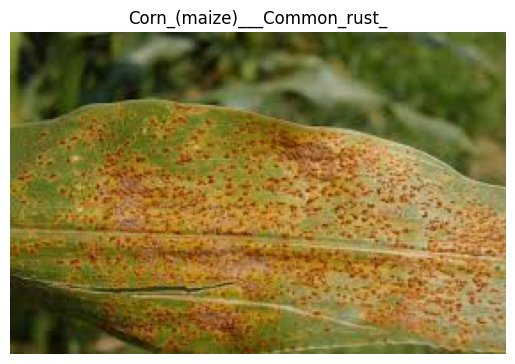

Sawirka: potato_blight.jpg


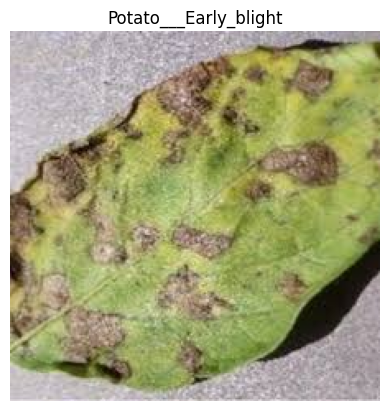

Sawirka: tomato_health.jpg


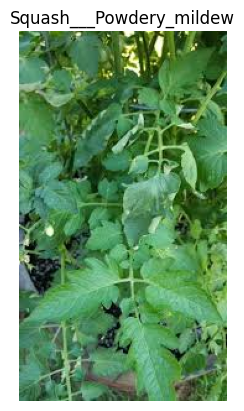

In [ ]:
# ---------------------------------------------------------
# Step 4: Testing the Model on Custom Images
# ---------------------------------------------------------

# List of image filenames to be tested (ensure these are uploaded to your directory)
test_images = ['corn_rust.jpg', 'potato_blight.jpg', 'tomato_health.jpg']

for img_name in test_images:
    # Check if the image file exists in the directory
    if not os.path.exists(img_name):
        print(f"Error: The file '{img_name}' was not found! Please ensure it is uploaded.")
        continue

    # Read the image using OpenCV
    img = cv2.imread(img_name)

    # Convert the image from BGR (OpenCV default) to RGB (Model requirement)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the image to 224x224 to match the model's input shape
    resize = tf.image.resize(img_rgb, (224, 224))

    # Add a batch dimension (e.g., from [224, 224, 3] to [1, 224, 224, 3])
    expand_data = np.expand_dims(resize, 0)

    # Perform the prediction
    prediction = model.predict(expand_data, verbose=0)

    # Get the index of the class with the highest probability
    predicted_index = np.argmax(prediction)

    # Retrieve the class name using the predicted index
    result_name = class_names[predicted_index]

    # Print and display the result
    print(f"Inference for image: {img_name}")

    plt.imshow(img_rgb)
    plt.title(f"Prediction: {result_name}")
    plt.axis('off') # Hide axes for a cleaner view
    plt.show()